In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r'C:\Users\sauda\Downloads\spotify_data clean.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [5]:
df.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


In [7]:
df.describe(include="O")

,track_id,track_name,artist_name,artist_genres,album_id,album_name,album_release_date,album_type
count,8582,8582,8579,5221,8582,8582,8582,8582
unique,8582,7462,2547,661,5205,4870,2384,3
top,61GEP8lryEfcuEgBMbRmNi,Home,Taylor Swift,soundtrack,3FFGbUutKWN1c4f0CJR4Uh,Nevermind (Super Deluxe Edition),2010-01-01,album
freq,1,8,324,345,70,70,76,5856


In [8]:
df.shape

(8582, 15)

In [9]:
list(df.columns)

['track_id',
 'track_name',
 'track_number',
 'track_popularity',
 'explicit',
 'artist_name',
 'artist_popularity',
 'artist_followers',
 'artist_genres',
 'album_id',
 'album_name',
 'album_release_date',
 'album_total_tracks',
 'album_type',
 'track_duration_min']

In [10]:
df.isna().sum()

track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

In [11]:
df[df["artist_name"].isna()]

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
1807,2NbsBSshscKIPRG3kwBbfo,Never Felt So Alone,1,68,False,NaN,0,0,NaN,33JqWTchq6piiQddrRIvJX,Never Felt So Alone,2023-04-07,1,single,2.66
6517,3QhfFRPkhPCR1RMJWV1gde,Radio,8,65,True,NaN,0,0,NaN,0Dt3FbpMQwjoT5KNAw0IXR,Born To Die – Paradise Edition (Special Version),2012-01-01,24,album,3.57
6679,5EhZC8GFOVXrpiUW22jncE,Urban Twilight,4,30,False,NaN,0,0,NaN,1Cog6aZ6NwnJiuINc0LQEU,Darkbloom,2011-04-18,5,single,4.26


In [12]:
df[df["track_name"]=="Radio"]

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
6516,3taCbWWTilb7eNMsAzOBq4,Radio,8,72,True,Lana Del Rey,88,51847587,"alternative pop, indie pop",5VoeRuTrGhTbKelUfwymwu,Born To Die - The Paradise Edition,2012-01-01,23,album,3.57
6517,3QhfFRPkhPCR1RMJWV1gde,Radio,8,65,True,NaN,0,0,NaN,0Dt3FbpMQwjoT5KNAw0IXR,Born To Die – Paradise Edition (Special Version),2012-01-01,24,album,3.57
6737,77RtpoGrwIbNh1E8rRCCX7,Radio,8,47,True,Lana Del Rey,88,51773650,"alternative pop, indie pop",0W4ETIlyIonfCfAykj3K59,Born To Die (Deluxe Version),2011-01-01,15,album,3.57


In [13]:
df.loc[df["track_name"] == "Radio", "artist_name"] ="Lana Del Rey"

In [14]:
df["artist_name"] = df["artist_name"].fillna(df["artist_name"].mode()[0])

In [15]:
df["artist_genres"] = df["artist_genres"].fillna(df["artist_genres"].mode()[0])

In [16]:
df.isna().sum()

track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64

In [17]:
df

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,soundtrack,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577,0AQquaENerGps8BQmbPw14,Big Iron,1,71,False,Marty Robbins,60,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,3.92
8578,4f8hBeMXMvssn6HtFAtblo,El Paso,10,64,False,Marty Robbins,61,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,4.32
8579,0Vy7wsXNFrbNc6UTWoScnM,Over the Rainbow,5,8,False,The Mystics,27,18184,doo-wop,2ifB9Xjp9DdpqLlYlY60QW,Presenting The Mystics,1959-02-11,9,compilation,2.28
8580,760clbeDBWmBsBLbszWuNZ,I'm A Man,2,55,False,Bo Diddley,44,333376,"blues, classic blues, rock and roll, rockabilly",1cbtDEwxCjMhglb49OgNBR,Bo Diddley,1958-01-01,12,album,2.74


In [18]:
df["explicit"] = df["explicit"].map({"True" : 1 , "False" : 0})

In [19]:
df["album_type"].value_counts()

album_type
album          5856
single         2219
compilation     507
Name: count, dtype: int64

In [20]:
df["explicit"] = df["explicit"].map({"album" :2 , "single" :1, "complication": 0})

In [21]:
df["album_release_date"] =pd.to_datetime(df["album_release_date"],dayfirst=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8582 non-null   object        
 1   track_name          8582 non-null   object        
 2   track_number        8582 non-null   int64         
 3   track_popularity    8582 non-null   int64         
 4   explicit            0 non-null      float64       
 5   artist_name         8582 non-null   object        
 6   artist_popularity   8582 non-null   int64         
 7   artist_followers    8582 non-null   int64         
 8   artist_genres       8582 non-null   object        
 9   album_id            8582 non-null   object        
 10  album_name          8582 non-null   object        
 11  album_release_date  8582 non-null   datetime64[ns]
 12  album_total_tracks  8582 non-null   int64         
 13  album_type          8582 non-null   object      

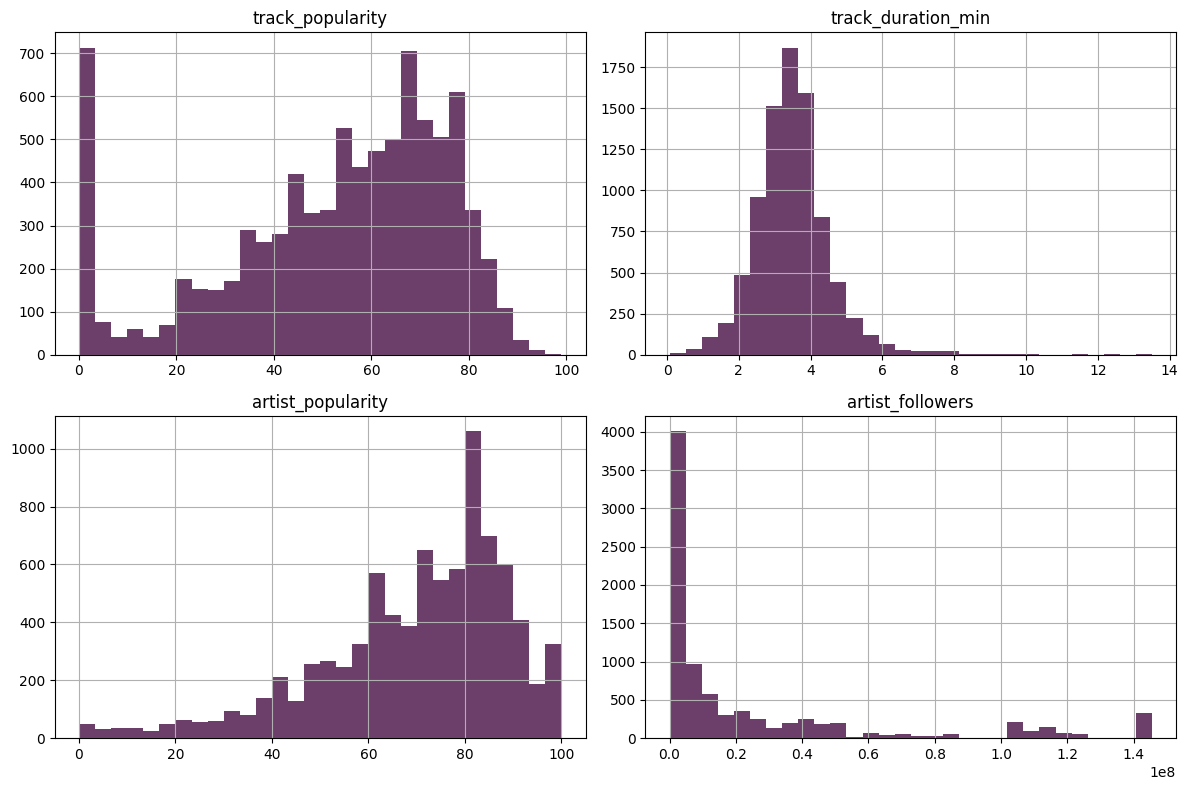

In [23]:
numeric_cols = ["track_popularity", "track_duration_min", "artist_popularity", "artist_followers"]
df[numeric_cols].hist(bins=30, figsize=(12, 8),color="#6B3F69")
plt.tight_layout()
plt.show()

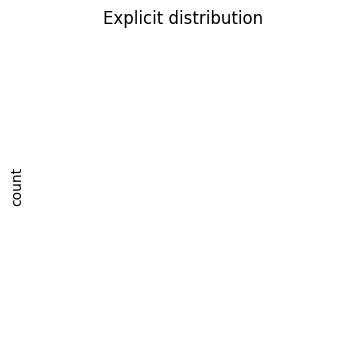

In [24]:
plt.figure(figsize=(6, 4))
df["explicit"].value_counts().plot(kind="pie")
plt.title("Explicit distribution")
plt.show()

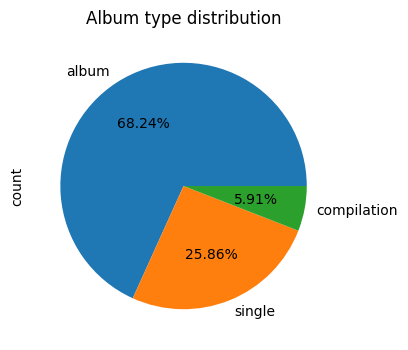

In [26]:
plt.figure(figsize=(6, 4))
df["album_type"].value_counts().plot(kind="pie", autopct="%1.2f%%")
plt.title("Album type distribution")
plt.show()